In [3]:
# =========================
# 1. Import Library
# =========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [13]:
df['Target'] = df['Exam_Score'].apply(lambda x: 1 if x >= 70 else 0)

In [14]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [15]:
X = df.drop(['Exam_Score', 'Target'], axis=1)
y = df['Target']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

# Scaling data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Training
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
# =========================
# 8. Evaluasi Model
# =========================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt
}

for name, model in models.items():
    pred = model.predict(X_test)
    
    print(f"\n===== {name} =====")
    
    # Accuracy
    print("Accuracy:", round(accuracy_score(y_test, pred), 3))
    
    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    
    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, pred))


===== Logistic Regression =====
Accuracy: 0.917
Confusion Matrix:
[[937  37]
 [ 73 275]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       974
           1       0.88      0.79      0.83       348

    accuracy                           0.92      1322
   macro avg       0.90      0.88      0.89      1322
weighted avg       0.92      0.92      0.92      1322


===== Decision Tree =====
Accuracy: 0.856
Confusion Matrix:
[[920  54]
 [137 211]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       974
           1       0.80      0.61      0.69       348

    accuracy                           0.86      1322
   macro avg       0.83      0.78      0.80      1322
weighted avg       0.85      0.86      0.85      1322



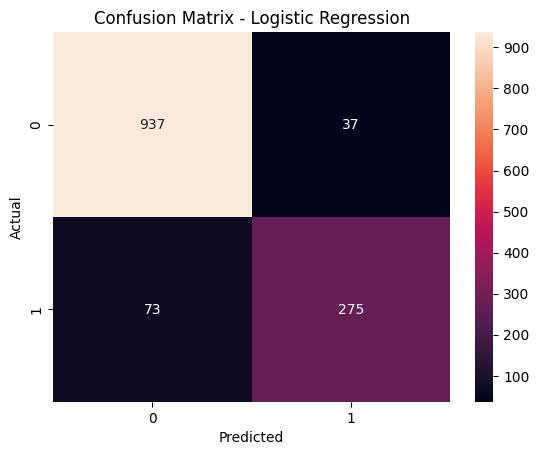

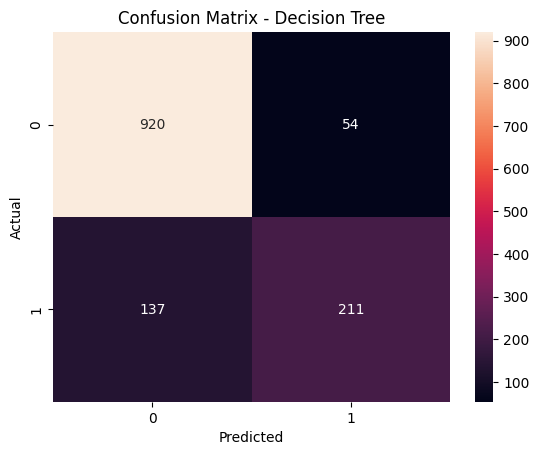

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# Confusion Matrix Logistic Regression
# =========================
cm_lr = confusion_matrix(y_test, lr.predict(X_test))

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# Confusion Matrix Decision Tree
# =========================
cm_dt = confusion_matrix(y_test, dt.predict(X_test))

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()